# (26) P-VAE + BALLS16

project = ```iP-VAE```, host = ```mach```, device = ```cuda:3```

**Motivation**: <br>


In [1]:
# HIDE CODE


import os, sys
from IPython.display import display

# tmp & extras dir
git_dir = os.path.join(os.environ['HOME'], 'Dropbox/git')
extras_dir = os.path.join(git_dir, 'jb-progress-2025/_extras')
fig_base_dir = os.path.join(git_dir, 'jb-progress-2025/figs')
tmp_dir = os.path.join(git_dir, 'jb-progress-2025/tmp')

# GitHub
sys.path.insert(0, os.path.join(git_dir, 'PoissonVAE'))
# from figures.analysis import plot_convergence
# from figures.imgs import plot_weights
from figures.fighelper import *
from main.train_vae import *

# warnings, tqdm, & style
warnings.filterwarnings('ignore', category=DeprecationWarning)
warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=UserWarning)
from rich.jupyter import print
%matplotlib inline
set_style()

In [2]:
device_idx = 3
device = f'cuda:{device_idx}'

print(f"device: {device}  ———  host: {os.uname().nodename}")

device: cuda:3  ———  host: mach

## Linear encoders

### poisson + <lin|lin>

In [3]:
model_type = 'poisson'
cfg_vae, cfg_tr = default_configs('BALLS', model_type, 'lin|lin')

cfg_vae['n_latents'] = 32

poisson_uniform_c(-4)_BALLS_z-32_fp_nrm-none_<lin|lin>
mc_b1000-ep1500-lr(0.005)_beta(1:0x0.5)_temp(0.05:lin-0.5)_gr(500)_(2025_02_26,16:25)

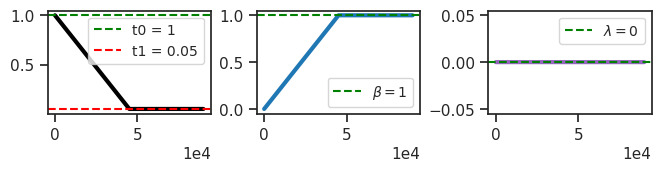

In [4]:
tr = TrainerVAE(
    model=MODEL_CLASSES[model_type](CFG_CLASSES[model_type](**cfg_vae)),
    cfg=ConfigTrainVAE(**cfg_tr),
    device=device,
)

# tr.model.print()
print(f"{tr.model.cfg.name()}\n{tr.cfg.name()}_({tr.model.timestamp})\n")
tr.show_schedules()

In [5]:
tr.train()

epoch # 1500, avg loss: 8.907136: 100%|█████| 1500/1500 [23:08<00:00,  1.08it/s]


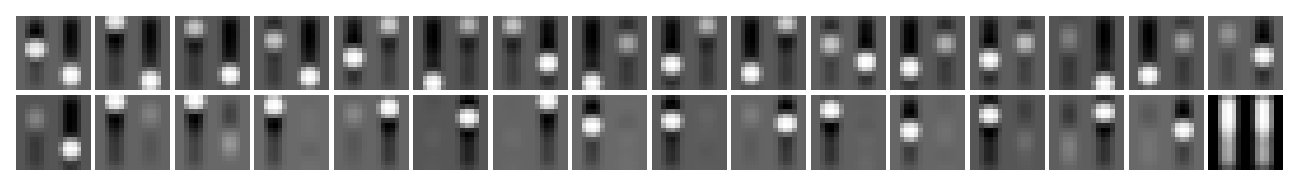

In [7]:
u0 = tonp(tr.model.log_rate.squeeze())
tr.model.show(order=np.argsort(u0), nrows=2);

### gaussian + <lin|lin>

In [3]:
model_type = 'gaussian'
cfg_vae, cfg_tr = default_configs('BALLS', model_type, 'lin|lin')

cfg_vae['n_latents'] = 32

gaussian_BALLS_z-32_nrm-none_<lin|lin>
mc_b1000-ep1500-lr(0.005)_beta(1:0x0.5)_gr(500)_(2025_02_26,16:54)

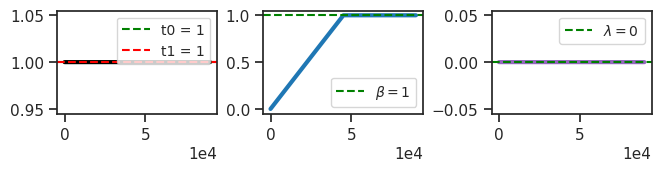

In [4]:
tr = TrainerVAE(
    model=MODEL_CLASSES[model_type](CFG_CLASSES[model_type](**cfg_vae)),
    cfg=ConfigTrainVAE(**cfg_tr),
    device=device,
)

# tr.model.print()
print(f"{tr.model.cfg.name()}\n{tr.cfg.name()}_({tr.model.timestamp})\n")
tr.show_schedules()

In [5]:
tr.train()

epoch # 1500, avg loss: 9.951699: 100%|█████| 1500/1500 [16:58<00:00,  1.47it/s]


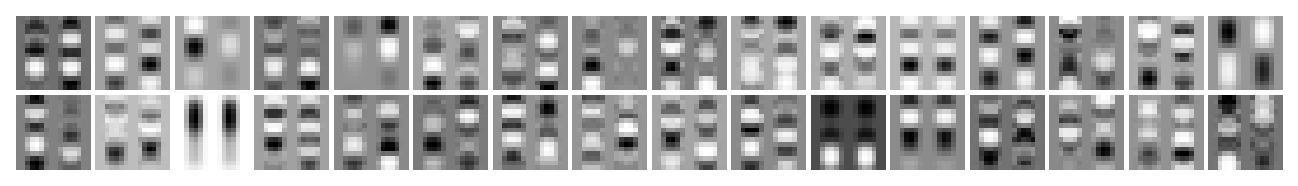

In [7]:
log_scale = tonp(tr.model.log_scale.squeeze())
tr.model.show(order=np.argsort(log_scale), nrows=2);

### gaussian + relu + <lin|lin>

In [8]:
model_type = 'gaussian'
cfg_vae, cfg_tr = default_configs('BALLS', model_type, 'lin|lin')

cfg_vae['n_latents'] = 32
cfg_vae['latent_act'] = 'relu'

gaussian_relu_BALLS_z-32_nrm-none_<lin|lin>
mc_b1000-ep1500-lr(0.005)_beta(1:0x0.5)_gr(500)_(2025_02_26,17:12)

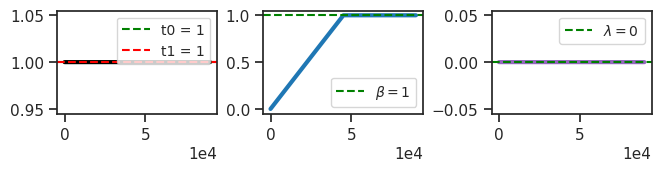

In [9]:
tr = TrainerVAE(
    model=MODEL_CLASSES[model_type](CFG_CLASSES[model_type](**cfg_vae)),
    cfg=ConfigTrainVAE(**cfg_tr),
    device=device,
)

# tr.model.print()
print(f"{tr.model.cfg.name()}\n{tr.cfg.name()}_({tr.model.timestamp})\n")
tr.show_schedules()

In [10]:
tr.train()

epoch # 1500, avg loss: 8.368303: 100%|█████| 1500/1500 [17:25<00:00,  1.43it/s]


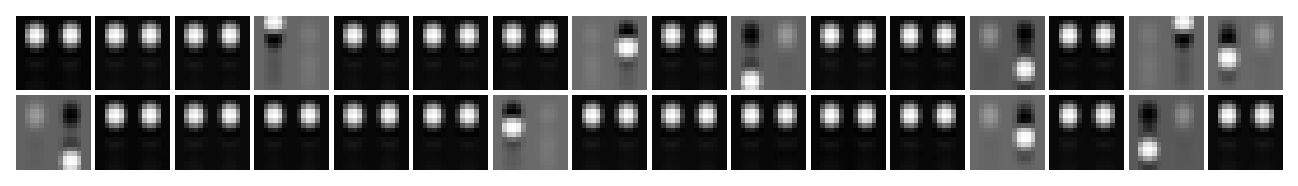

In [11]:
log_scale = tonp(tr.model.log_scale.squeeze())
tr.model.show(order=np.argsort(log_scale), nrows=2);

## Conv encoders

### poisson + <conv|lin>

In [12]:
model_type = 'poisson'
cfg_vae, cfg_tr = default_configs('BALLS', model_type, 'conv|lin')

cfg_vae['n_latents'] = 32

poisson_uniform_c(-4)_BALLS_z-32_k-32_fp_nrm-none_<conv|lin>
mc_b1000-ep1500-lr(0.005)_beta(1:0x0.5)_temp(0.05:lin-0.5)_gr(500)_(2025_02_26,17:33)

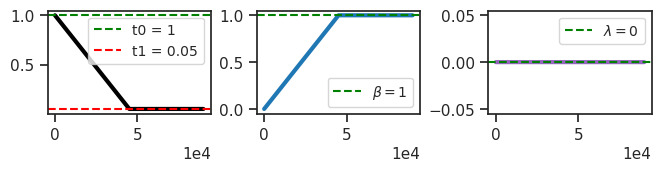

In [13]:
tr = TrainerVAE(
    model=MODEL_CLASSES[model_type](CFG_CLASSES[model_type](**cfg_vae)),
    cfg=ConfigTrainVAE(**cfg_tr),
    device=device,
)

# tr.model.print()
print(f"{tr.model.cfg.name()}\n{tr.cfg.name()}_({tr.model.timestamp})\n")
tr.show_schedules()

In [14]:
tr.train()

epoch # 1500, avg loss: 8.892070: 100%|███| 1500/1500 [1:27:12<00:00,  3.49s/it]


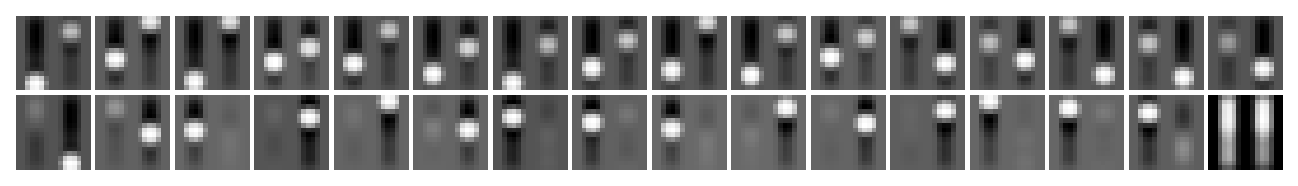

In [15]:
u0 = tonp(tr.model.log_rate.squeeze())
tr.model.show(order=np.argsort(u0), nrows=2);

### gaussian + <lin|lin>

In [16]:
model_type = 'gaussian'
cfg_vae, cfg_tr = default_configs('BALLS', model_type, 'conv|lin')

cfg_vae['n_latents'] = 32

gaussian_BALLS_z-32_k-32_nrm-none_<conv|lin>
mc_b1000-ep1500-lr(0.005)_beta(1:0x0.5)_gr(500)_(2025_02_26,19:00)

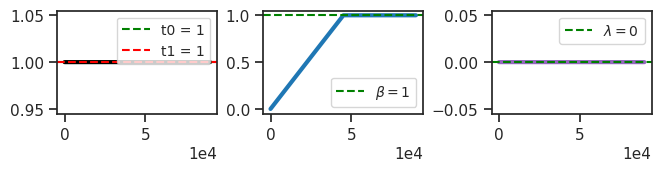

In [17]:
tr = TrainerVAE(
    model=MODEL_CLASSES[model_type](CFG_CLASSES[model_type](**cfg_vae)),
    cfg=ConfigTrainVAE(**cfg_tr),
    device=device,
)

# tr.model.print()
print(f"{tr.model.cfg.name()}\n{tr.cfg.name()}_({tr.model.timestamp})\n")
tr.show_schedules()

In [18]:
tr.train()

epoch # 1500, avg loss: 9.958686: 100%|███| 1500/1500 [1:20:53<00:00,  3.24s/it]


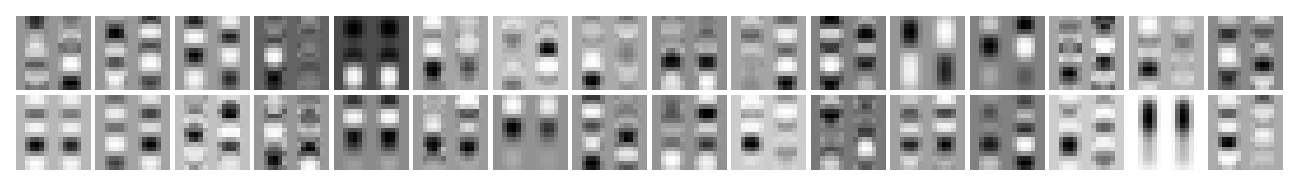

In [19]:
log_scale = tonp(tr.model.log_scale.squeeze())
tr.model.show(order=np.argsort(log_scale), nrows=2);

### gaussian + relu + <lin|lin>

In [20]:
model_type = 'gaussian'
cfg_vae, cfg_tr = default_configs('BALLS', model_type, 'conv|lin')

cfg_vae['n_latents'] = 32
cfg_vae['latent_act'] = 'relu'

gaussian_relu_BALLS_z-32_k-32_nrm-none_<conv|lin>
mc_b1000-ep1500-lr(0.005)_beta(1:0x0.5)_gr(500)_(2025_02_26,20:21)

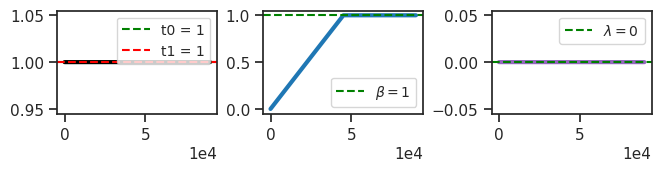

In [21]:
tr = TrainerVAE(
    model=MODEL_CLASSES[model_type](CFG_CLASSES[model_type](**cfg_vae)),
    cfg=ConfigTrainVAE(**cfg_tr),
    device=device,
)

# tr.model.print()
print(f"{tr.model.cfg.name()}\n{tr.cfg.name()}_({tr.model.timestamp})\n")
tr.show_schedules()

In [22]:
tr.train()

epoch # 1500, avg loss: 8.260689: 100%|███| 1500/1500 [1:20:55<00:00,  3.24s/it]


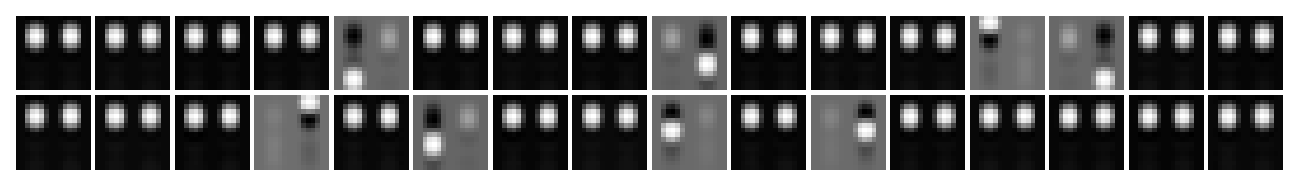

In [23]:
log_scale = tonp(tr.model.log_scale.squeeze())
tr.model.show(order=np.argsort(log_scale), nrows=2);